# 05 — XGBoost on LightGBM Top-N Features

## Goal
Use trained LightGBM as a feature selector for XGBoost.
LightGBM's leaf-wise growth naturally surfaces engineered features (confirmed: positions 7–19 in top-30).
XGBoost trained on LightGBM's top-100 features gets guaranteed exposure to engineered features.

**This notebook is a pure orchestrator — all logic lives in `src/pipeline_feature_selection.py`.**

## Approach
```
Step 1 — Load splits + load trained LightGBM (no retraining)
Step 2 — Extract top-100 features from LightGBM importance
Step 3 — Show breakdown: how many engineered vs V-columns vs raw
Step 4 — Filter X_train / X_val / X_test → top-100 only
Step 5 — Train XGBoost (default params) on filtered splits
Step 6 — Predict on Val + Test independently
Step 7 — Evaluate Val (informational)
Step 8 — Evaluate Test vs V0 TEST baseline (primary comparison)
Step 9 — Final comparison table: all experiments vs V0 TEST baseline
Step 10 — Conclusion: is Optuna justified?
```

## nb04 Reference Results (Test — unbiased)
```
V0 Baseline       : Test ROC 0.8953  Test PR 0.5033  ← must beat
nb04 LightGBM     : Test ROC 0.8963  Test PR 0.5045  ← best PR so far
nb04 XGBoost      : Test ROC 0.8971  Test PR 0.4944  ← PR below baseline
nb04 Ensemble     : Test ROC 0.8998  Test PR 0.5034  ← best ROC
```

## Step 1 — Imports & Setup

In [1]:
import sys, os, pickle, warnings
warnings.filterwarnings('ignore')

# Notebook lives in v2/ — go one level up to reach project root
PROJECT_ROOT_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
for subdir in ['', 'src', 'v0']:
    p = os.path.join(PROJECT_ROOT_PATH, subdir)
    if p not in sys.path:
        sys.path.insert(0, p)

from config import PROJECT_ROOT, PREPROC_DIR, OUTPUTS_DIR
from pipeline_evaluate import load_splits
from pipeline_feature_selection import (
    load_lgbm_model,
    get_top_features,
    print_feature_breakdown,
    filter_splits,
    train_xgb_on_top_n,
    evaluate_model,
    print_comparison_table,
)
import xgboost as xgb_lib

MODELS_DIR = OUTPUTS_DIR / 'models'

# V0 TEST baseline — the only reference that matters
V0_TEST_ROC = 0.8953
V0_TEST_PR  = 0.5033

# nb04 results for final comparison
NB04_RESULTS = {
    'nb04 LightGBM':    {'test_roc': 0.8963, 'test_pr': 0.5045},
    'nb04 XGBoost':     {'test_roc': 0.8971, 'test_pr': 0.4944},
    'nb04 Ensemble':    {'test_roc': 0.8998, 'test_pr': 0.5034},
}

# Flag: if model already saved — skip retraining
RETRAIN_XGB = False
MODEL_PATH  = MODELS_DIR / 'model_xgb_top_n.pkl'

# Number of top features to select
TOP_N = 100

print(f'Project root : {PROJECT_ROOT}')
print(f'Preproc dir  : {PREPROC_DIR}')
print(f'Models dir   : {MODELS_DIR}')
print(f'RETRAIN_XGB  : {RETRAIN_XGB}')
print(f'TOP_N        : {TOP_N}')

Project root : C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection
Preproc dir  : C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\preproc
Models dir   : C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\models
RETRAIN_XGB  : False
TOP_N        : 100


## Step 2 — Load Splits + Trained LightGBM

In [2]:
# Load preprocessed splits
X_train, X_val, X_test, encoding_map, y_train, y_val, y_test = load_splits(PREPROC_DIR)

# Load trained LightGBM — no retraining, use nb04 model
model_lgbm = load_lgbm_model(MODELS_DIR / 'model_lgbm.pkl')

STEP 1 — Load preprocessed splits
   X_train_lgbm : (354324, 459)  | fraud rate: 3.3833%
   X_val_lgbm   : (118108, 459)    | fraud rate: 3.9041%  (early stopping)
   X_test_lgbm  : (118108, 459)   | fraud rate: 3.4409%  (frozen TEST)
   encoding_map : 32 encoders
   Loaded LightGBM <- C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\models\model_lgbm.pkl


## Step 3 — Extract Top-N Features from LightGBM

In [3]:
top_features = get_top_features(
    model_lgbm,
    feature_names = X_train.columns.tolist(),
    top_n         = TOP_N,
)

TOP-100 FEATURES FROM LIGHTGBM
   Rank   Feature                               Importance
   ───────────────────────────────────────────────────────
   1      card1                                      12047
   2      tx_day                                     10133
   3      TransactionAmt                              9716
   4      card2                                       9294
   5      addr1                                       7830
   6      tx_dom                                      6292
   7      tx_amt_mean                                 5554  ◄ engineered
   8      tx_hour                                     5377
   9      tx_amt_max                                  5325  ◄ engineered
   10     tx_amt_std                                  5310  ◄ engineered
   11     hour_vs_typical                             5303  ◄ engineered
   12     tx_amt_min                                  4897  ◄ engineered
   13     delta_amt                                   4780  ◄ engineered


## Step 4 — Feature Breakdown: Engineered vs V-columns vs Raw

In [4]:
breakdown = print_feature_breakdown(top_features)

FEATURE BREAKDOWN IN TOP-N
   Total selected    : 100
   Engineered (ours) : 17  → ['tx_amt_mean', 'tx_amt_max', 'tx_amt_std', 'hour_vs_typical', 'tx_amt_min', 'delta_amt', 'time_since_last_tx', 'amt_vs_personal_median', 'uid_time_entropy', 'tx_amt_ratio', 'amt_z_score', 'tx_count', 'tx_count_last_30d', 'tx_count_last_7d', 'tx_count_last_3d', 'nunique_P_email', 'nunique_R_email']
   V-columns         : 27
   Raw features      : 56


## Step 5 — Filter Splits to Top-N Features

In [5]:
X_train_f, X_val_f, X_test_f = filter_splits(X_train, X_val, X_test, top_features)

FILTERED SPLITS
   X_train : (354324, 459) → (354324, 100)
   X_val   : (118108, 459)   → (118108, 100)
   X_test  : (118108, 459)  → (118108, 100)  (frozen TEST)


## Step 6 — Train XGBoost (default params) on Top-N Features

In [6]:
if RETRAIN_XGB or not MODEL_PATH.exists():
    model_xgb_topn, y_pred_val = train_xgb_on_top_n(
        X_train_f, y_train,
        X_val_f,   y_val,
        models_dir = MODELS_DIR,
    )
else:
    with open(MODEL_PATH, 'rb') as f:
        model_xgb_topn = pickle.load(f)
    dval       = xgb_lib.DMatrix(X_val_f)
    y_pred_val = model_xgb_topn.predict(
        dval, iteration_range=(0, model_xgb_topn.best_iteration + 1)
    ).astype('float32')
    print(f'Loaded model_xgb_top_n <- {MODEL_PATH}')

TRAINING — XGBoost on Top-N Features (default params)

   Params         : {'objective': 'binary:logistic', 'eval_metric': 'auc', 'tree_method': 'hist', 'scale_pos_weight': 28, 'max_depth': 6, 'eta': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.3, 'colsample_bylevel': 0.5, 'min_child_weight': 100, 'seed': 42, 'verbosity': 0}
   num_rounds     : 3000
   early_stopping : 100

   Train : 354,324 rows × 100 features
   Val   : 118,108 rows × 100 features
[0]	train-auc:0.82674	val-auc:0.83443
[100]	train-auc:0.92134	val-auc:0.90445
[200]	train-auc:0.94453	val-auc:0.91554
[300]	train-auc:0.95646	val-auc:0.91965
[400]	train-auc:0.96427	val-auc:0.92179
[500]	train-auc:0.97037	val-auc:0.92225
[600]	train-auc:0.97500	val-auc:0.92244
[700]	train-auc:0.97852	val-auc:0.92221
[800]	train-auc:0.98155	val-auc:0.92236
[864]	train-auc:0.98339	val-auc:0.92179

   Best iteration : 764
   Best val AUC   : 0.922700

   Model saved → C:\Users\USER\Desktop\NOTEBOOKS\HIT\ML_Fraud_detection\outputs\models\mode

## Step 7 — Predict on Test

In [7]:
dtest        = xgb_lib.DMatrix(X_test_f)
y_pred_test  = model_xgb_topn.predict(
    dtest, iteration_range=(0, model_xgb_topn.best_iteration + 1)
).astype('float32')

## Step 8 — Evaluate on Val (informational)

  Val RESULTS — XGBoost Top-100
  Model                         ROC AUC    PR AUC
  ────────────────────────────────────────────────
  V0 Baseline (Test)             0.8953    0.5033
  XGBoost Top-100                0.9227    0.5737   Δ ROC=+0.0274  Δ PR=+0.0704


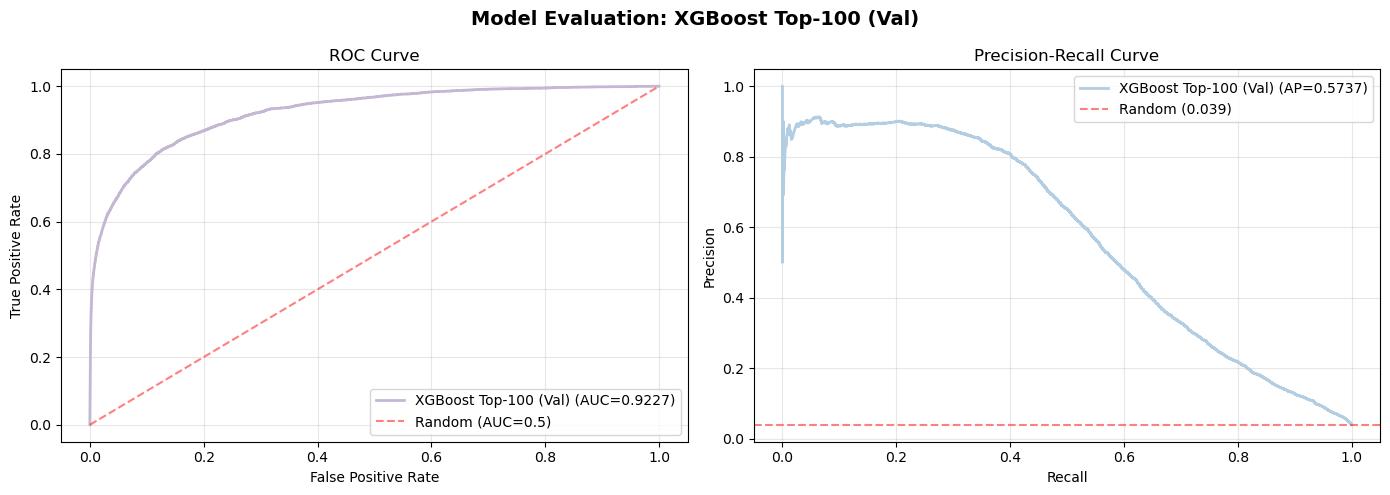

>> Top 30 features by importance:
     1. C8                              importance: 2222.572998046875
     2. C10                             importance: 1134.4208984375
     3. C12                             importance: 986.5967407226562
     4. V317                            importance: 898.5248413085938
     5. C14                             importance: 877.5538940429688
     6. C5                              importance: 658.6231689453125
     7. card6                           importance: 583.1905517578125
     8. D12                             importance: 582.2609252929688
     9. V308                            importance: 581.3944702148438
    10. C11                             importance: 418.28302001953125
    11. C1                              importance: 389.78167724609375
    12. M4                              importance: 383.1025085449219
    13. V283                            importance: 367.418212890625
    14. V45                             importance: 358.5

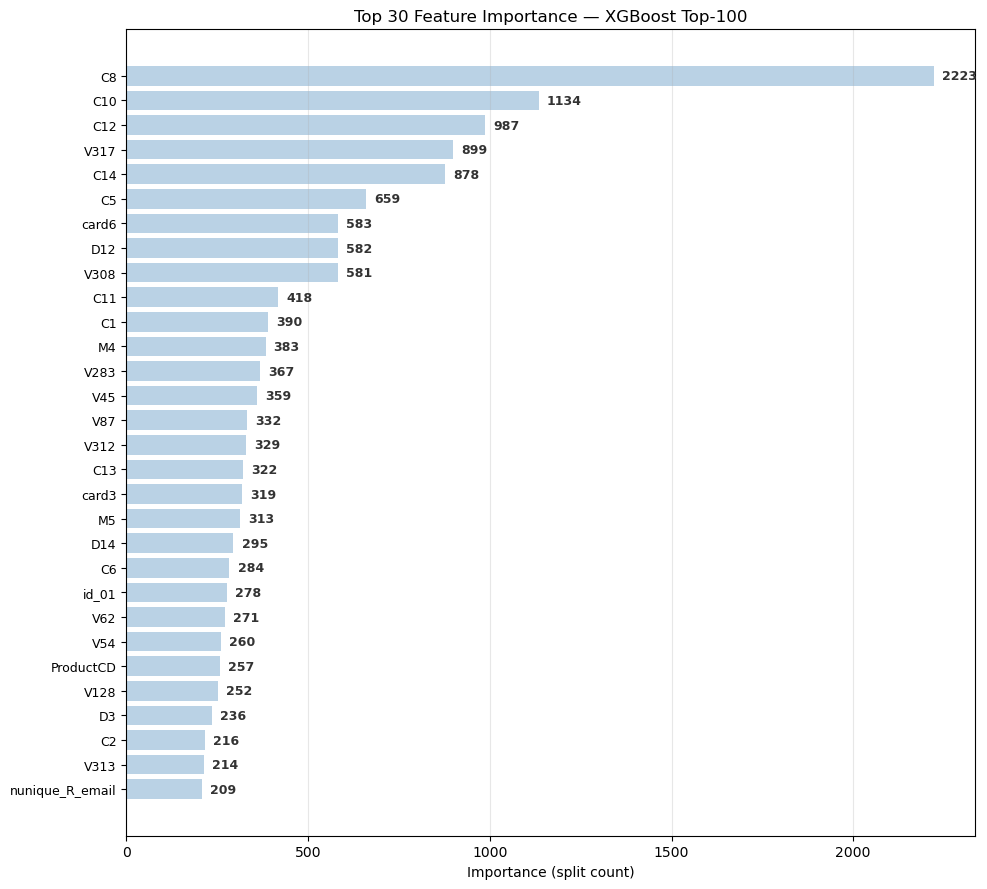

In [8]:
val_roc, val_pr = evaluate_model(
    y_val, y_pred_val,
    model_name   = 'XGBoost Top-100',
    v0_test_roc  = V0_TEST_ROC,
    v0_test_pr   = V0_TEST_PR,
    split_name   = 'Val',
    show_plot    = True,
    model        = model_xgb_topn,
    feature_names = top_features,
)

## Step 9 — Evaluate on Frozen TEST vs V0 TEST Baseline

> ⚠️ **Primary comparison — Test metrics are the only unbiased evaluation.**
> Val metrics are influenced by Optuna tuning and cannot be used as final comparison.

  Test RESULTS — XGBoost Top-100
  Model                         ROC AUC    PR AUC
  ────────────────────────────────────────────────
  V0 Baseline (Test)             0.8953    0.5033
  XGBoost Top-100                0.8882    0.4610   Δ ROC=-0.0071  Δ PR=-0.0423


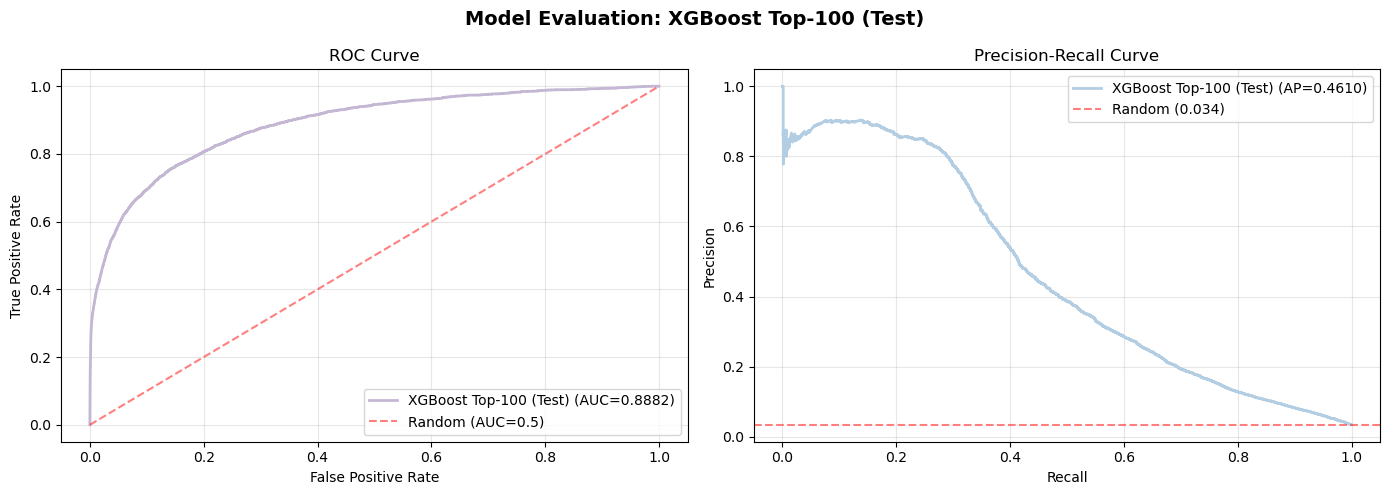

In [9]:
test_roc, test_pr = evaluate_model(
    y_test, y_pred_test,
    model_name   = 'XGBoost Top-100',
    v0_test_roc  = V0_TEST_ROC,
    v0_test_pr   = V0_TEST_PR,
    split_name   = 'Test',
    show_plot    = True,
)

## Step 10 — Final Comparison Table

In [10]:
all_results = {
    **NB04_RESULTS,
    'XGBoost Top-100 (default)': {'test_roc': test_roc, 'test_pr': test_pr},
}

print_comparison_table(all_results, V0_TEST_ROC, V0_TEST_PR)

FINAL COMPARISON — ALL MODELS vs V0 TEST BASELINE
  Model                             Test ROC   Test PR    Δ ROC     Δ PR
  ────────────────────────────────────────────────────────────────────
  V0 Baseline                         0.8953    0.5033        —        —
  nb04 LightGBM                       0.8963    0.5045  +0.0010  +0.0012
  nb04 XGBoost                        0.8971    0.4944  +0.0018  -0.0089
  nb04 Ensemble                       0.8998    0.5034  +0.0045  +0.0001
  XGBoost Top-100 (default)           0.8882    0.4610  -0.0071  -0.0423


## Step 11 — Conclusion

**Decision rule:**
- If `XGBoost Top-100 Test PR > nb04 XGBoost Test PR (0.4944)` → feature selection helps → run Optuna
- If `XGBoost Top-100 Test PR > nb04 LightGBM Test PR (0.5045)` → strong result → Optuna is high priority
- If no improvement → reconsider approach (different TOP_N, or focus on LightGBM improvements instead)